# NGC4254 nGIST KIN failure evidence chain

This notebook reconstructs the local evidence for the NGC4254 Setonix run that passed `READ_DATA`, spatial masking, Voronoi binning, and `PREPARE_SPECTRA`, then failed in the stellar kinematics module with:

```text
IndexError: tuple index out of range
EBV[i] = ppxf_tmp[i][8]
```

The goal is to separate observed artifacts from interpretation:

1. What the latest `LOGFILE` says happened.
2. What the downloaded mask and bin maps show.
3. What the binned spectra HDF5 file contains.
4. Why the EBV tuple error is secondary.
5. What should be tested or patched next on Setonix.

## 1. Local inputs used

The notebook only uses local files downloaded under `v3tk_v7.6.8/NGC4254` plus local nGIST source/config files for code-path evidence. If one of these files changes, rerun the notebook before using the conclusions.

In [1]:
from pathlib import Path
from datetime import datetime
import re

import h5py
import numpy as np
from astropy.io import fits

# In Jupyter, use the inline backend so rerunning cells displays plots.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

ROOT = Path("/Users/Igniz/Desktop/ICRAR/further")
RUN_DIR = ROOT / "v3tk_v7.6.8" / "NGC4254"
LOGFILE = RUN_DIR / "LOGFILE"
CONFIG = RUN_DIR / "CONFIG"
MASK_CURRENT = RUN_DIR / "NGC4254_mask.fits"
MASK_FAIL = RUN_DIR / "NGC4254_mask_fail.fits"
BINMAP = RUN_DIR / "NGC4254_spatial_binning_maps.fits"
BINSPEC = RUN_DIR / "NGC4254_bin_spectra.hdf5"

PPXF_WRAPPER = Path("/Users/Igniz/nGISTENV/ngist/ngistPipeline/stellarKinematics/ppxf_kin_wrapper.py")
PREPARE_SPECTRA = Path("/Users/Igniz/nGISTENV/ngist/ngistPipeline/prepareSpectra/default.py")
MUSE_WFMAON = Path("/Users/Igniz/nGISTENV/ngist/ngistPipeline/readData/MUSE_WFMAON.py")
KIN_MASK = Path("/Users/Igniz/Desktop/ICRAR/nGIST_v7.6.8_setup/config_setup/specMask_KIN_narrow10_AO")

paths = [LOGFILE, CONFIG, MASK_CURRENT, MASK_FAIL, BINMAP, BINSPEC, PPXF_WRAPPER, PREPARE_SPECTRA, MUSE_WFMAON, KIN_MASK]
missing = [p for p in paths if not p.exists()]
assert not missing, "Missing required files: " + ", ".join(str(p) for p in missing)

print("Using local evidence files:")
for p in paths:
    size_mb = p.stat().st_size / 1024**2
    mtime = datetime.fromtimestamp(p.stat().st_mtime).strftime("%Y-%m-%d %H:%M:%S")
    print(f"- {p}  ({size_mb:,.1f} MiB, mtime {mtime})")

Using local evidence files:
- /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4254/LOGFILE  (0.0 MiB, mtime 2026-06-10 10:20:53)
- /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4254/CONFIG  (0.0 MiB, mtime 2026-06-09 17:00:23)
- /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4254/NGC4254_mask.fits  (9.2 MiB, mtime 2026-06-09 17:09:58)
- /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4254/NGC4254_mask_fail.fits  (9.2 MiB, mtime 2026-06-08 17:31:05)
- /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4254/NGC4254_spatial_binning_maps.fits  (55.2 MiB, mtime 2026-06-10 00:39:22)
- /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4254/NGC4254_bin_spectra.hdf5  (2,794.6 MiB, mtime 2026-06-10 11:40:37)
- /Users/Igniz/nGISTENV/ngist/ngistPipeline/stellarKinematics/ppxf_kin_wrapper.py  (0.0 MiB, mtime 2025-12-16 11:33:46)
- /Users/Igniz/nGISTENV/ngist/ngistPipeline/prepareSpectra/default.py  (0.0 MiB, mtime 2025-12-16 11:33:46)
- /Users/Igniz/nGISTENV/ngist/ngistPipeline/readData/M

## 2. Latest run timeline from `LOGFILE`

This cell extracts the final run block from the downloaded `LOGFILE` and turns the important stages into elapsed-time bars. The key check is whether the 7.5 hr Voronoi stage is consistent with the local binning artifacts.

Latest run key events:
- run start         : line  225  2026-06-09 09:00:23  _initialise: 
- finished readData : line  242  2026-06-09 09:07:22  MUSE_WFMAON: Finished reading the MUSE cube! Read a total of 1204280 spectra!
- combined mask     : line  247  2026-06-09 09:09:58  default: Combined mask: 161822 spaxels are rejected.
- voronoi start     : line  250  2026-06-09 09:09:59  voronoi: Defining the Voronoi bins
- voronoi bins      : line  251  2026-06-09 16:38:58  voronoi: 40563 Voronoi bins generated!
- prepare start     : line  254  2026-06-09 16:39:22  _prepareSpectra: Using the routine for default
- bin spectra written: line  261  2026-06-09 16:51:36  default: Wrote: /scratch/pawsey1308/mauve/products/v3tk_v7.6.8/NGC4254/NGC4254_bin_spectra.hdf5
- KIN start         : line  262  2026-06-09 16:51:37  _stellarKinematics: Using the stellarKinematics routine 'ppxf_kin_wrapper.py'
- KIN failure       : line  268  2026-06-09 17:01:49  _stellarKinematics: tuple index out of range


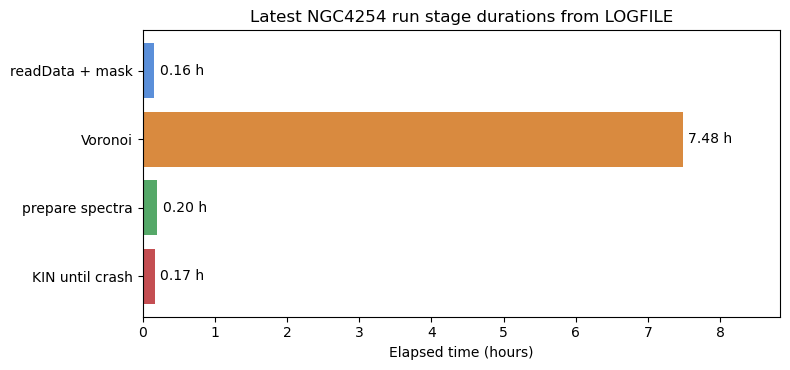

In [2]:
log_text = LOGFILE.read_text(errors="replace")
log_lines = log_text.splitlines()
line_re = re.compile(r"^(\d{2}/\d{2}/\d{2} \d{2}:\d{2}:\d{2}) -\s+(\w+)\s+-\s+(.*)$")
records = []
for lineno, line in enumerate(log_lines, start=1):
    m = line_re.match(line)
    if m:
        dt = datetime.strptime(m.group(1), "%m/%d/%y %H:%M:%S")
        records.append((lineno, dt, m.group(2), m.group(3), line))

start_indices = [i for i, rec in enumerate(records) if "_initialise" in rec[3]]
assert start_indices, "No _initialise records found"
latest = records[start_indices[-1]:]


def find_first(substr):
    for rec in latest:
        if substr in rec[3] or substr in rec[4]:
            return rec
    return None

events = {
    "run start": latest[0],
    "finished readData": find_first("Finished reading the MUSE cube"),
    "combined mask": find_first("Combined mask:"),
    "voronoi start": find_first("voronoi: Defining the Voronoi bins"),
    "voronoi bins": find_first("Voronoi bins generated"),
    "prepare start": find_first("_prepareSpectra: Using"),
    "bin spectra written": find_first("_bin_spectra.hdf5"),
    "KIN start": find_first("_stellarKinematics: Using"),
    "KIN failure": find_first("tuple index out of range"),
}

print("Latest run key events:")
for name, rec in events.items():
    if rec is None:
        print(f"- {name:18s}: not found")
    else:
        print(f"- {name:18s}: line {rec[0]:4d}  {rec[1]}  {rec[3]}")

stage_pairs = [
    ("readData + mask", events["run start"], events["combined mask"]),
    ("Voronoi", events["voronoi start"], events["voronoi bins"]),
    ("prepare spectra", events["prepare start"], events["bin spectra written"]),
    ("KIN until crash", events["KIN start"], events["KIN failure"]),
]
stages = []
for label, a, b in stage_pairs:
    if a is not None and b is not None:
        stages.append((label, (b[1] - a[1]).total_seconds() / 3600.0))

fig, ax = plt.subplots(figsize=(8, 3.8))
labels = [s[0] for s in stages]
hours = [s[1] for s in stages]
y = np.arange(len(stages))
ax.barh(y, hours, color=["#5b8fd9", "#d98a3f", "#55a868", "#c44e52"])
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xlabel("Elapsed time (hours)")
ax.set_title("Latest NGC4254 run stage durations from LOGFILE")
for yi, h in zip(y, hours):
    ax.text(h + max(hours) * 0.01, yi, f"{h:.2f} h", va="center")
ax.set_xlim(0, max(hours) * 1.18)
fig.tight_layout()
plt.show()

## 3. Mask evidence

The earlier failed mask rejected every spaxel as defunct. The current mask no longer does that, which confirms the run progressed past the original read/masking failure. The current mask leaves more than one million unmasked spaxels for Voronoi binning.

Current mask total spaxels: 1,204,280
Failed mask total spaxels:  1,204,280

Counts by mask column and value:

current:
  MASK         0=1,042,458, 1=161,822
  MASK_DEFUNCT 0=1,043,737, 1=160,543
  MASK_SNR     0=1,204,280
  MASK_FILE    0=1,202,980, 1=1,300

previous failed:
  MASK         1=1,204,280
  MASK_DEFUNCT 1=1,204,280
  MASK_SNR     0=1,204,280
  MASK_FILE    0=1,202,980, 1=1,300


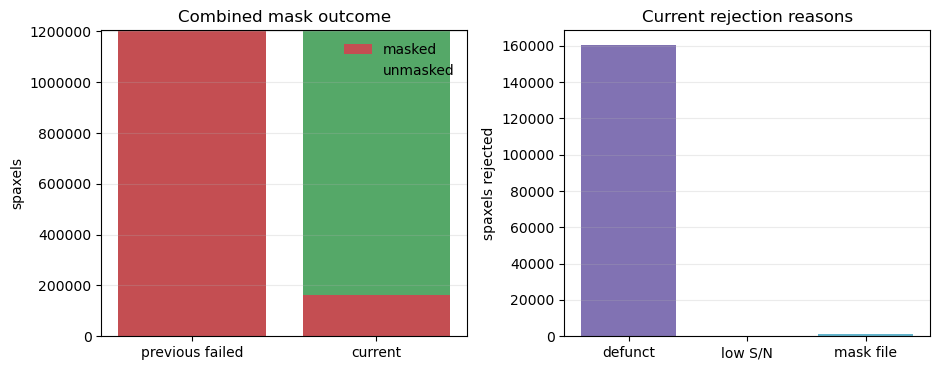

In [3]:
def mask_counts(path):
    with fits.open(path, memmap=True) as hdul:
        data = hdul[1].data
        out = {name: dict(zip(*np.unique(np.asarray(data[name]), return_counts=True))) for name in data.names}
        total = len(data)
    return total, out

mask_total, current_counts = mask_counts(MASK_CURRENT)
fail_total, fail_counts = mask_counts(MASK_FAIL)

print(f"Current mask total spaxels: {mask_total:,}")
print(f"Failed mask total spaxels:  {fail_total:,}")
print("\nCounts by mask column and value:")
for label, counts in [("current", current_counts), ("previous failed", fail_counts)]:
    print(f"\n{label}:")
    for col, col_counts in counts.items():
        print(f"  {col:12s} " + ", ".join(f"{int(k)}={int(v):,}" for k, v in sorted(col_counts.items())))

current_unmasked = current_counts["MASK"].get(0, 0)
current_masked = current_counts["MASK"].get(1, 0)
fail_unmasked = fail_counts["MASK"].get(0, 0)
fail_masked = fail_counts["MASK"].get(1, 0)

fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.8))
axs[0].bar(["previous failed", "current"], [fail_masked, current_masked], label="masked", color="#c44e52")
axs[0].bar(["previous failed", "current"], [fail_unmasked, current_unmasked], bottom=[fail_masked, current_masked], label="unmasked", color="#55a868")
axs[0].set_ylabel("spaxels")
axs[0].set_title("Combined mask outcome")
axs[0].legend(frameon=False)
axs[0].ticklabel_format(axis="y", style="plain")

reason_labels = ["defunct", "low S/N", "mask file"]
reason_cols = ["MASK_DEFUNCT", "MASK_SNR", "MASK_FILE"]
reason_vals = [current_counts[c].get(1, 0) for c in reason_cols]
axs[1].bar(reason_labels, reason_vals, color=["#8172b3", "#ccb974", "#64b5cd"])
axs[1].set_title("Current rejection reasons")
axs[1].set_ylabel("spaxels rejected")
axs[1].ticklabel_format(axis="y", style="plain")
for ax in axs:
    ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## 4. Voronoi binning evidence

The bin map is the local product of the slow Voronoi stage. This confirms the run did generate a valid-looking bin map with finite S/N products, but the binning problem was very large.

BINID map shape: (1190, 1012)
Finite unmasked map pixels: 1,042,458
Unique Voronoi bins: 40,563
Median pixels per bin: 8.0
SNR per spaxel median/p99/max: 4.734 / 25.669 / 87.573
SNRBIN median/p99/max: 41.895 / 47.739 / 89.337


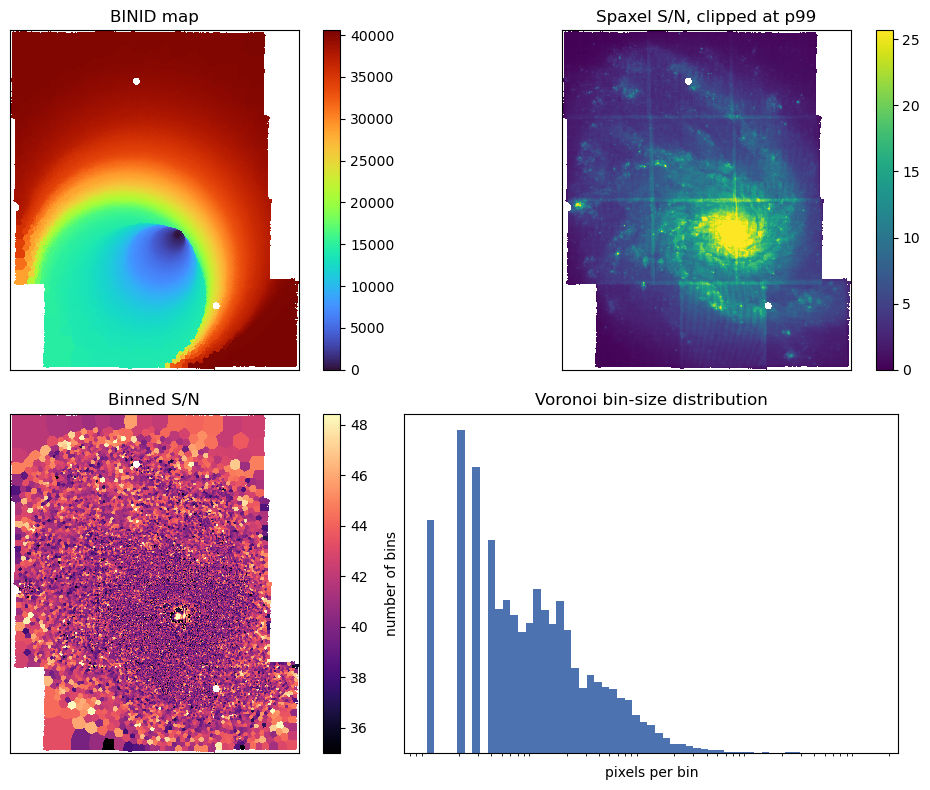

In [4]:
with fits.open(BINMAP, memmap=True) as hdul:
    binid = np.asarray(hdul["BINID"].data, dtype=float)
    flux = np.asarray(hdul["FLUX"].data, dtype=float)
    snr = np.asarray(hdul["SNR"].data, dtype=float)
    snrbin = np.asarray(hdul["SNRBIN"].data, dtype=float)

valid = np.isfinite(binid) & (binid >= 0)
valid_binids, pix_per_bin = np.unique(binid[valid].astype(int), return_counts=True)
nbins = len(valid_binids)
unmasked_from_map = int(valid.sum())

print(f"BINID map shape: {binid.shape}")
print(f"Finite unmasked map pixels: {unmasked_from_map:,}")
print(f"Unique Voronoi bins: {nbins:,}")
print(f"Median pixels per bin: {np.median(pix_per_bin):.1f}")
print(f"SNR per spaxel median/p99/max: {np.nanmedian(snr):.3f} / {np.nanpercentile(snr, 99):.3f} / {np.nanmax(snr):.3f}")
print(f"SNRBIN median/p99/max: {np.nanmedian(snrbin):.3f} / {np.nanpercentile(snrbin, 99):.3f} / {np.nanmax(snrbin):.3f}")

fig, axs = plt.subplots(2, 2, figsize=(11, 8))
masked_binid = np.ma.masked_invalid(binid)
im0 = axs[0, 0].imshow(masked_binid, origin="lower", cmap="turbo", interpolation="nearest")
axs[0, 0].set_title("BINID map")
fig.colorbar(im0, ax=axs[0, 0], fraction=0.046)

im1 = axs[0, 1].imshow(np.ma.masked_invalid(snr), origin="lower", cmap="viridis", vmin=0, vmax=np.nanpercentile(snr, 99), interpolation="nearest")
axs[0, 1].set_title("Spaxel S/N, clipped at p99")
fig.colorbar(im1, ax=axs[0, 1], fraction=0.046)

im2 = axs[1, 0].imshow(np.ma.masked_invalid(snrbin), origin="lower", cmap="magma", vmin=35, vmax=np.nanpercentile(snrbin, 99.5), interpolation="nearest")
axs[1, 0].set_title("Binned S/N")
fig.colorbar(im2, ax=axs[1, 0], fraction=0.046)

axs[1, 1].hist(pix_per_bin, bins=np.geomspace(max(1, pix_per_bin.min()), pix_per_bin.max(), 60), color="#4c72b0")
axs[1, 1].set_xscale("log")
axs[1, 1].set_xlabel("pixels per bin")
axs[1, 1].set_ylabel("number of bins")
axs[1, 1].set_title("Voronoi bin-size distribution")
for ax in axs.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()

## 5. Binned spectra HDF5 scan

pPXF requires the complete noise vector to be positive and finite before fitting. This scan checks the saved `SPEC` and `ESPEC` arrays in `NGC4254_bin_spectra.hdf5` without loading the whole file at once.

In [5]:
with h5py.File(BINSPEC, "r") as f:
    print("HDF5 datasets:")
    for name in f:
        d = f[name]
        print(f"- {name:6s}: shape={d.shape}, dtype={d.dtype}")
    print("attributes:", dict(f.attrs))

    loglam = f["LOGLAM"][:]
    wave = np.exp(loglam)
    err = f["ESPEC"]
    spec = f["SPEC"]
    nlam, nh5bins = err.shape

    bad_cols = set()
    bad_row_counts = np.zeros(nlam, dtype=int)
    nonfinite_row_counts = np.zeros(nlam, dtype=int)
    nonpositive_row_counts = np.zeros(nlam, dtype=int)
    block_rows = 128

    for r0 in range(0, nlam, block_rows):
        r1 = min(nlam, r0 + block_rows)
        e = err[r0:r1, :]
        nonfinite = ~np.isfinite(e)
        nonpositive = e <= 0
        bad = nonfinite | nonpositive
        if bad.any():
            rows, cols = np.where(bad)
            bad_cols.update(cols.astype(int).tolist())
            bad_row_counts[r0:r1] += bad.sum(axis=1)
            nonfinite_row_counts[r0:r1] += nonfinite.sum(axis=1)
            nonpositive_row_counts[r0:r1] += nonpositive.sum(axis=1)

    bad_ids = np.array(sorted(bad_cols), dtype=int)
    bad_rows = np.where(bad_row_counts > 0)[0]
    first_bad = int(bad_ids[0]) if bad_ids.size else None
    spec_nonfinite_in_bad_cols = int((~np.isfinite(spec[:, bad_ids])).sum()) if bad_ids.size else 0

print(f"LOGLAM length: {len(loglam):,}")
print(f"Rest-frame wavelength range: {wave[0]:.3f} - {wave[-1]:.3f} A")
print(f"HDF5 bin count: {nh5bins:,}")
print(f"Bins with any bad ESPEC value: {len(bad_ids):,}")
print(f"First bad BINID/column: {first_bad}")
print(f"SPEC non-finite values in those bad columns: {spec_nonfinite_in_bad_cols:,}")
print("Bad wavelength rows:")
for r in bad_rows:
    print(f"  row {r:4d}  wave={wave[r]:.6f} A  bad={bad_row_counts[r]:3d}  nonfinite={nonfinite_row_counts[r]:3d}  nonpositive={nonpositive_row_counts[r]:3d}")

HDF5 datasets:
- ESPEC : shape=(4515, 40563), dtype=float64
- LOGLAM: shape=(4515,), dtype=float64
- SPEC  : shape=(4515, 40563), dtype=float64
attributes: {'CDELT1': np.float64(0.00013676127903039514), 'CRPIX1': np.float64(1.0), 'CRVAL1': np.float64(8.476356945631172), 'VELSCALE': np.int64(41)}
LOGLAM length: 4,515
Rest-frame wavelength range: 4799.932 - 8899.028 A
HDF5 bin count: 40,563
Bins with any bad ESPEC value: 185
First bad BINID/column: 9718
SPEC non-finite values in those bad columns: 0
Bad wavelength rows:
  row 1896  wave=6220.815775 A  bad=138  nonfinite=138  nonpositive=  0
  row 1897  wave=6221.666600 A  bad=185  nonfinite=185  nonpositive=  0
  row 1898  wave=6222.517541 A  bad=185  nonfinite=185  nonpositive=  0
  row 1899  wave=6223.368599 A  bad=185  nonfinite=185  nonpositive=  0
  row 1900  wave=6224.219773 A  bad=185  nonfinite=185  nonpositive=  0
  row 1901  wave=6225.071063 A  bad= 86  nonfinite= 86  nonpositive=  0
  row 1902  wave=6225.922470 A  bad= 86  non

## 6. The bad `ESPEC` pixels are wavelength-localized

All affected bins share the same small rest-frame wavelength interval. This is not the AO/LGS fill window after the redshift correction, and it is not covered by the current KIN spectral mask.

AO/LGS fill/check interval after rest-frame shift: 5724.059 - 6001.829 A rest
Bad ESPEC interval: 6220.816 - 6225.922 A rest
Observed-frame equivalent of bad interval: 6270.744 - 6275.892 A
KIN mask entries covering bad rows: none


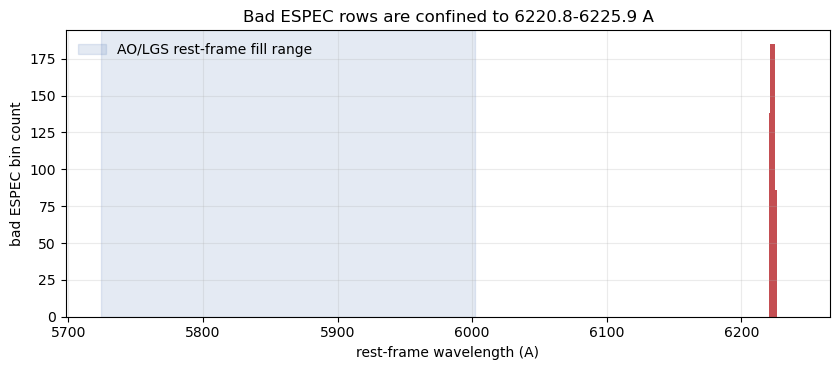

In [6]:
z = 0.008026
lgs_rest_lo = 5770 / (1 + z)
lgs_rest_hi = 6050 / (1 + z)
obs_bad = wave[bad_rows] * (1 + z)
print(f"AO/LGS fill/check interval after rest-frame shift: {lgs_rest_lo:.3f} - {lgs_rest_hi:.3f} A rest")
print(f"Bad ESPEC interval: {wave[bad_rows].min():.3f} - {wave[bad_rows].max():.3f} A rest")
print(f"Observed-frame equivalent of bad interval: {obs_bad.min():.3f} - {obs_bad.max():.3f} A")

# Check KIN mask coverage for the affected wavelength rows.
mask = np.genfromtxt(KIN_MASK, comments="#", usecols=(0, 1))
comments = np.genfromtxt(KIN_MASK, comments="#", usecols=(2,), dtype=str)
covered = []
for cen, width, comment in zip(mask[:, 0], mask[:, 1], comments):
    center_rest = cen / (1 + z) if str(comment).lower() == "sky" else cen
    lo = center_rest - width / 2
    hi = center_rest + width / 2
    hits = wave[bad_rows][(wave[bad_rows] >= lo) & (wave[bad_rows] <= hi)]
    if hits.size:
        covered.append((cen, width, comment, lo, hi, hits.tolist()))
print("KIN mask entries covering bad rows:", covered if covered else "none")

fig, ax = plt.subplots(figsize=(8.5, 3.8))
window = (wave > 6205) & (wave < 6240)
ax.bar(wave[window], bad_row_counts[window], width=np.median(np.diff(wave)), color="#c44e52", align="center")
ax.axvspan(lgs_rest_lo, lgs_rest_hi, color="#4c72b0", alpha=0.15, label="AO/LGS rest-frame fill range")
ax.set_xlabel("rest-frame wavelength (A)")
ax.set_ylabel("bad ESPEC bin count")
ax.set_title("Bad ESPEC rows are confined to 6220.8-6225.9 A")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 7. Representative bad bin spectrum

The first bad binned spectrum has a finite science spectrum but a short NaN segment in the error/noise spectrum. pPXF rejects this before it has a chance to use the spectral mask.

Representative bad BINID: 9718
Nearby good comparison BINID: 9698
Bad rows for BINID 9718: [1896, 1897, 1898, 1899, 1900]
row 1891  wave=6216.563  SPEC_bad=     553.8  ESPEC_bad=12.955991739091502
row 1892  wave=6217.414  SPEC_bad=     564.7  ESPEC_bad=12.595170039103603
row 1893  wave=6218.264  SPEC_bad=     585.3  ESPEC_bad=12.783520902517138
row 1894  wave=6219.114  SPEC_bad=     598.6  ESPEC_bad=12.846083487549604
row 1895  wave=6219.965  SPEC_bad=     567.5  ESPEC_bad=12.004338077066047
row 1896  wave=6220.816  SPEC_bad=     564.9  ESPEC_bad=nan
row 1897  wave=6221.667  SPEC_bad=     558.4  ESPEC_bad=nan
row 1898  wave=6222.518  SPEC_bad=     535.6  ESPEC_bad=nan
row 1899  wave=6223.369  SPEC_bad=     562.9  ESPEC_bad=nan
row 1900  wave=6224.220  SPEC_bad=     567.9  ESPEC_bad=nan
row 1901  wave=6225.071  SPEC_bad=       553  ESPEC_bad=12.564448863066142
row 1902  wave=6225.922  SPEC_bad=     563.6  ESPEC_bad=12.874165275902168
row 1903  wave=6226.774  SPEC_bad=     566.6  ESPEC_b

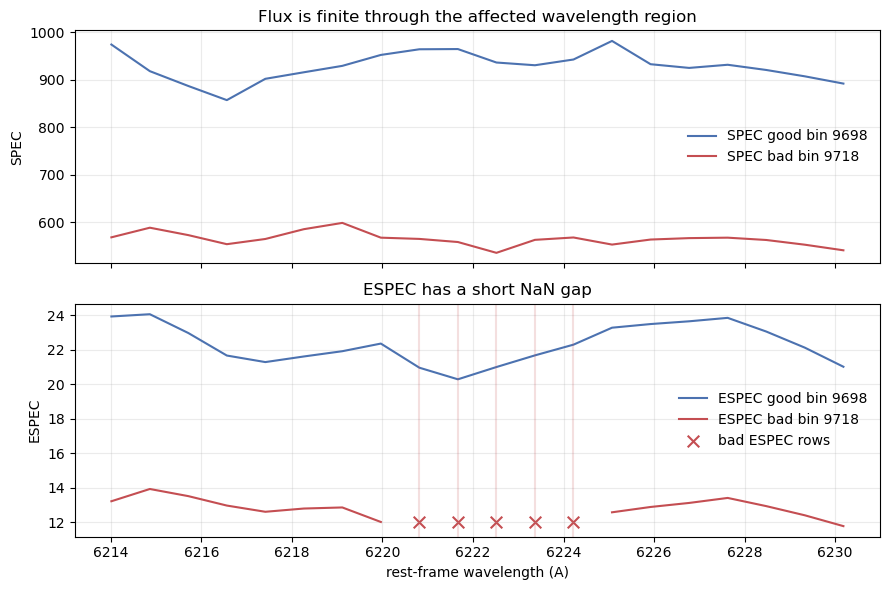

In [7]:
bad_set = set(bad_ids.tolist())
good_id = None
for candidate in range(max(0, first_bad - 20), min(nh5bins, first_bad + 50)):
    if candidate not in bad_set:
        good_id = candidate
        break
assert good_id is not None

with h5py.File(BINSPEC, "r") as f:
    spec_bad = f["SPEC"][:, first_bad]
    err_bad = f["ESPEC"][:, first_bad]
    spec_good = f["SPEC"][:, good_id]
    err_good = f["ESPEC"][:, good_id]

bad_err_rows = np.where(~np.isfinite(err_bad) | (err_bad <= 0))[0]
print(f"Representative bad BINID: {first_bad}")
print(f"Nearby good comparison BINID: {good_id}")
print(f"Bad rows for BINID {first_bad}: {bad_err_rows.tolist()}")
for r in range(bad_err_rows.min() - 5, bad_err_rows.max() + 6):
    print(f"row {r:4d}  wave={wave[r]:8.3f}  SPEC_bad={spec_bad[r]:10.4g}  ESPEC_bad={err_bad[r]}")

zoom = (wave > 6214) & (wave < 6231)
fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axs[0].plot(wave[zoom], spec_good[zoom], color="#4c72b0", lw=1.5, label=f"SPEC good bin {good_id}")
axs[0].plot(wave[zoom], spec_bad[zoom], color="#c44e52", lw=1.5, label=f"SPEC bad bin {first_bad}")
axs[0].set_ylabel("SPEC")
axs[0].legend(frameon=False)
axs[0].set_title("Flux is finite through the affected wavelength region")

axs[1].plot(wave[zoom], err_good[zoom], color="#4c72b0", lw=1.5, label=f"ESPEC good bin {good_id}")
axs[1].plot(wave[zoom], err_bad[zoom], color="#c44e52", lw=1.5, label=f"ESPEC bad bin {first_bad}")
axs[1].scatter(wave[bad_err_rows], np.full_like(bad_err_rows, np.nanmedian(err_bad[zoom])), color="#c44e52", marker="x", s=70, label="bad ESPEC rows")
for r in bad_err_rows:
    axs[1].axvline(wave[r], color="#c44e52", alpha=0.18)
axs[1].set_ylabel("ESPEC")
axs[1].set_xlabel("rest-frame wavelength (A)")
axs[1].legend(frameon=False)
axs[1].set_title("ESPEC has a short NaN gap")
for ax in axs:
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 8. Spatial distribution of affected bins

The 185 affected Voronoi bins are mostly isolated and spread across the field, not one contiguous failed region. That is consistent with a sparse variance/error defect that contaminates specific binned error pixels.

Bad Voronoi bins: 185
Map pixels belonging to bad bins: 40,771
Full bad-bin pixel y range: 1 - 1188
Full bad-bin pixel x range: 1 - 997
First bad bin 9718 contains 10 map pixels


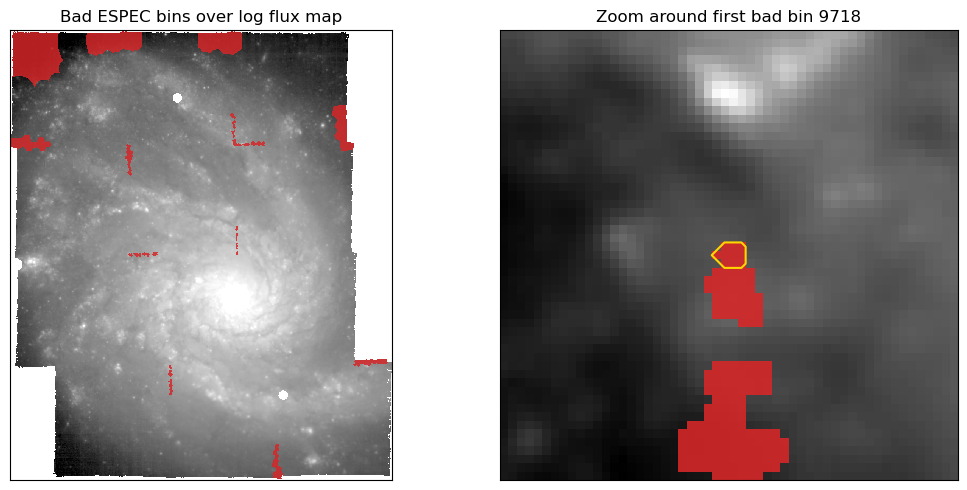

In [8]:
bad_pixel_mask = np.isin(binid.astype(float), bad_ids.astype(float))
y_bad, x_bad = np.where(bad_pixel_mask)
y_first, x_first = np.where(binid == first_bad)

print(f"Bad Voronoi bins: {len(bad_ids):,}")
print(f"Map pixels belonging to bad bins: {int(bad_pixel_mask.sum()):,}")
print(f"Full bad-bin pixel y range: {int(y_bad.min())} - {int(y_bad.max())}")
print(f"Full bad-bin pixel x range: {int(x_bad.min())} - {int(x_bad.max())}")
print(f"First bad bin {first_bad} contains {len(y_first)} map pixels")

background = np.ma.masked_invalid(np.log10(np.clip(flux, np.nanpercentile(flux[valid], 1), np.nanpercentile(flux[valid], 99.5))))
red_overlay = np.ma.masked_where(~bad_pixel_mask, bad_pixel_mask)

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].imshow(background, origin="lower", cmap="gray", interpolation="nearest")
axs[0].imshow(red_overlay, origin="lower", cmap=ListedColormap(["#d62728"]), alpha=0.85, interpolation="nearest")
axs[0].set_title("Bad ESPEC bins over log flux map")
axs[0].set_xticks([])
axs[0].set_yticks([])

pad = 25
y0 = max(0, int(y_first.min()) - pad)
y1 = min(binid.shape[0], int(y_first.max()) + pad + 1)
x0 = max(0, int(x_first.min()) - pad)
x1 = min(binid.shape[1], int(x_first.max()) + pad + 1)
axs[1].imshow(background[y0:y1, x0:x1], origin="lower", cmap="gray", interpolation="nearest")
axs[1].imshow(red_overlay[y0:y1, x0:x1], origin="lower", cmap=ListedColormap(["#d62728"]), alpha=0.9, interpolation="nearest")
axs[1].contour((binid[y0:y1, x0:x1] == first_bad).astype(float), levels=[0.5], colors="#ffd700", linewidths=1.5)
axs[1].set_title(f"Zoom around first bad bin {first_bad}")
axs[1].set_xticks([])
axs[1].set_yticks([])
fig.tight_layout()
plt.show()

Bad Voronoi bins: 185
Map pixels belonging to bad bins: 40,771
Full bad-bin pixel y range: 1 - 1188
Full bad-bin pixel x range: 1 - 997
First bad bin 9718 contains 10 map pixels


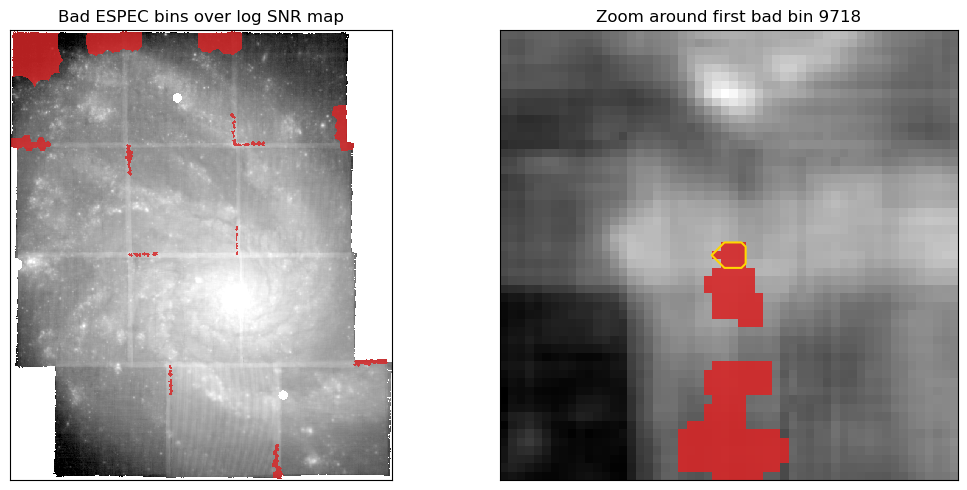

In [9]:
bad_pixel_mask = np.isin(binid.astype(float), bad_ids.astype(float))
y_bad, x_bad = np.where(bad_pixel_mask)
y_first, x_first = np.where(binid == first_bad)

print(f"Bad Voronoi bins: {len(bad_ids):,}")
print(f"Map pixels belonging to bad bins: {int(bad_pixel_mask.sum()):,}")
print(f"Full bad-bin pixel y range: {int(y_bad.min())} - {int(y_bad.max())}")
print(f"Full bad-bin pixel x range: {int(x_bad.min())} - {int(x_bad.max())}")
print(f"First bad bin {first_bad} contains {len(y_first)} map pixels")

background = np.ma.masked_invalid(np.log10(np.clip(snr, np.nanpercentile(snr[valid], 1), np.nanpercentile(snr[valid], 99.5))))
red_overlay = np.ma.masked_where(~bad_pixel_mask, bad_pixel_mask)

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
axs[0].imshow(background, origin="lower", cmap="gray", interpolation="nearest")
axs[0].imshow(red_overlay, origin="lower", cmap=ListedColormap(["#d62728"]), alpha=0.85, interpolation="nearest")
axs[0].set_title("Bad ESPEC bins over log SNR map")
axs[0].set_xticks([])
axs[0].set_yticks([])

pad = 25
y0 = max(0, int(y_first.min()) - pad)
y1 = min(binid.shape[0], int(y_first.max()) + pad + 1)
x0 = max(0, int(x_first.min()) - pad)
x1 = min(binid.shape[1], int(x_first.max()) + pad + 1)
axs[1].imshow(background[y0:y1, x0:x1], origin="lower", cmap="gray", interpolation="nearest")
axs[1].imshow(red_overlay[y0:y1, x0:x1], origin="lower", cmap=ListedColormap(["#d62728"]), alpha=0.9, interpolation="nearest")
axs[1].contour((binid[y0:y1, x0:x1] == first_bad).astype(float), levels=[0.5], colors="#ffd700", linewidths=1.5)
axs[1].set_title(f"Zoom around first bad bin {first_bad}")
axs[1].set_xticks([])
axs[1].set_yticks([])
fig.tight_layout()
plt.show()

## 8b. FLUX HDU map with problematic bins highlighted

This plot uses the `FLUX` image HDU from `NGC4254_spatial_binning_maps.fits` as the background and overlays every Voronoi bin whose binned `ESPEC` vector contains at least one non-finite or non-positive value. Red pixels are all map pixels belonging to problematic bins; cyan circles mark their bin centroids. Several representative `BINID`s are labelled so the spatial positions can be cross-checked against the spectra below.

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_44672/1941641001.py:26: RuntimeWarning: invalid value encountered in cast
  bad_bin_pixel_mask = np.isin(binid.astype(int, copy=False), bad_ids)


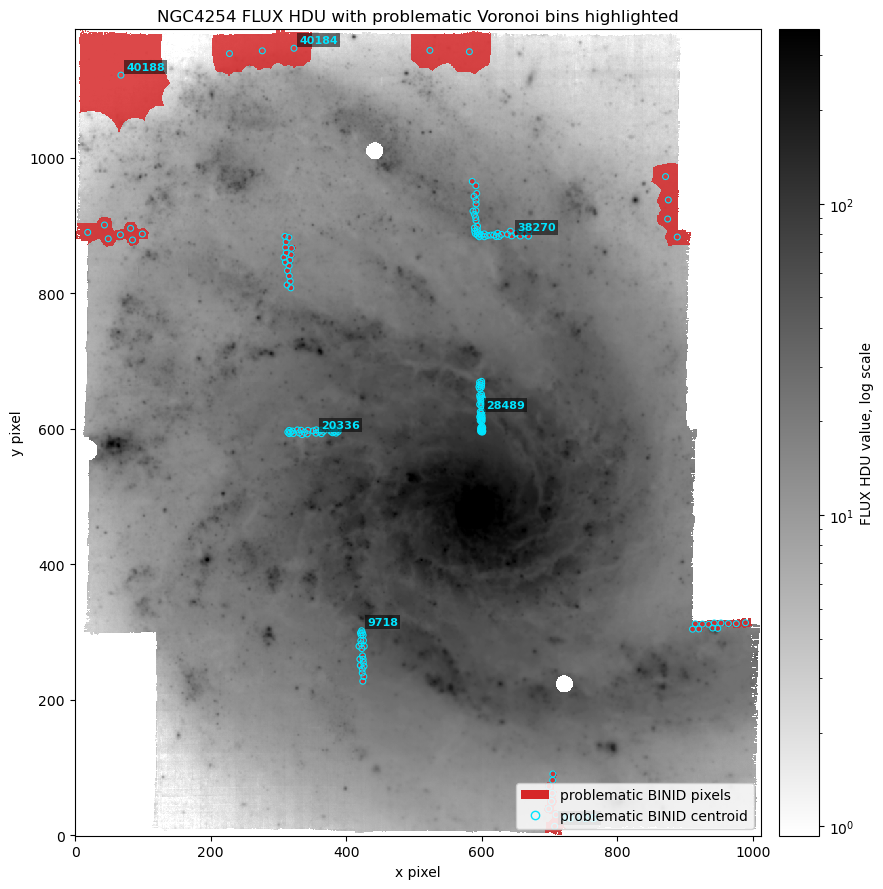

Problematic bins highlighted: 185
Problematic-bin pixels highlighted: 40771
Labelled BINIDs: [9718, 40435, 20336, 28489, 38270, 40184, 40188]


In [10]:
# CODEx NGC4254 extra diagnostic cell: FLUX HDU map with problematic bins highlighted
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Build per-problem-bin spatial metadata from BINID and FLUX HDUs.
problem_bin_spatial = []
for bid in bad_ids:
    m = binid == bid
    y, x = np.where(m)
    if y.size == 0:
        continue
    problem_bin_spatial.append({
        "BINID": int(bid),
        "npix": int(y.size),
        "y_mean": float(y.mean()),
        "x_mean": float(x.mean()),
        "y_min": int(y.min()),
        "y_max": int(y.max()),
        "x_min": int(x.min()),
        "x_max": int(x.max()),
        "flux_median": float(np.nanmedian(flux[m])),
        "snrbin_median": float(np.nanmedian(snrbin[m])),
    })

bad_bin_pixel_mask = np.isin(binid.astype(int, copy=False), bad_ids)
positive_flux = flux[np.isfinite(flux) & (flux > 0)]
vmin = np.nanpercentile(positive_flux, 1)
vmax = np.nanpercentile(positive_flux, 99.7)

# Representative labels: first bad bin, four spatial quantiles, largest affected bin.
spatial_sorted = sorted(problem_bin_spatial, key=lambda r: (r["y_mean"], r["x_mean"]))
label_ids = []
for idx in [0, len(spatial_sorted)//4, len(spatial_sorted)//2, 3*len(spatial_sorted)//4, len(spatial_sorted)-1]:
    bid = spatial_sorted[idx]["BINID"]
    if bid not in label_ids:
        label_ids.append(bid)
largest = max(problem_bin_spatial, key=lambda r: r["npix"])["BINID"]
if largest not in label_ids:
    label_ids.append(largest)
if first_bad not in label_ids:
    label_ids.insert(0, first_bad)
label_ids = label_ids[:8]

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(np.ma.masked_invalid(flux), origin="lower", cmap="gray_r", norm=LogNorm(vmin=vmin, vmax=vmax), interpolation="nearest")
ax.imshow(np.ma.masked_where(~bad_bin_pixel_mask, bad_bin_pixel_mask), origin="lower", cmap=ListedColormap(["#d62728"]), alpha=0.85, interpolation="nearest")
centers = np.array([[r["x_mean"], r["y_mean"], r["BINID"]] for r in problem_bin_spatial])
ax.scatter(centers[:, 0], centers[:, 1], s=18, facecolors="none", edgecolors="#00e5ff", linewidths=0.8)

for bid in label_ids:
    row = next(r for r in problem_bin_spatial if r["BINID"] == bid)
    ax.text(row["x_mean"] + 8, row["y_mean"] + 8, str(bid), color="#00e5ff", fontsize=8, weight="bold",
            bbox=dict(facecolor="black", alpha=0.55, edgecolor="none", pad=1.5))

ax.set_title("NGC4254 FLUX HDU with problematic Voronoi bins highlighted")
ax.set_xlabel("x pixel")
ax.set_ylabel("y pixel")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label("FLUX HDU value, log scale")
legend_items = [
    Patch(facecolor="#d62728", edgecolor="none", label="problematic BINID pixels"),
    Line2D([0], [0], marker="o", color="none", markeredgecolor="#00e5ff", markerfacecolor="none", label="problematic BINID centroid"),
]
ax.legend(handles=legend_items, loc="lower right", frameon=True, facecolor="white", framealpha=0.85)
fig.tight_layout()
plt.show()

print(f"Problematic bins highlighted: {len(problem_bin_spatial)}")
print(f"Problematic-bin pixels highlighted: {int(bad_bin_pixel_mask.sum())}")
print("Labelled BINIDs:", label_ids)

## 8c. Details for every problematic bin

For each problematic `BINID`, this table lists the contiguous wavelength range(s) where `ESPEC` is bad, plus basic spatial metadata from the `BINID` and `FLUX` HDUs. The rest-frame ranges are what pPXF sees; the observed-frame ranges are computed with `z = 0.008026`.

In [11]:
# CODEx NGC4254 extra diagnostic cell: every problematic BINID and wavelength range

def contiguous_ranges(indices):
    indices = np.asarray(indices, dtype=int)
    if indices.size == 0:
        return []
    runs = []
    start = prev = int(indices[0])
    for value in indices[1:]:
        value = int(value)
        if value == prev + 1:
            prev = value
        else:
            runs.append((start, prev))
            start = prev = value
    runs.append((start, prev))
    return runs

spatial_by_id = {r["BINID"]: r for r in problem_bin_spatial}
problem_bin_details = []
with h5py.File(BINSPEC, "r") as f:
    err = f["ESPEC"]
    for bid in bad_ids:
        e = err[:, int(bid)]
        bad = np.where(~np.isfinite(e) | (e <= 0))[0]
        ranges = contiguous_ranges(bad)
        rest_ranges = [f"{wave[a]:.3f}-{wave[b]:.3f}" if a != b else f"{wave[a]:.3f}" for a, b in ranges]
        obs_ranges = [f"{wave[a]*(1+z):.3f}-{wave[b]*(1+z):.3f}" if a != b else f"{wave[a]*(1+z):.3f}" for a, b in ranges]
        row = spatial_by_id[int(bid)]
        problem_bin_details.append({
            "BINID": int(bid),
            "n_bad_pix": int(bad.size),
            "bad_rows": ",".join(str(int(x)) for x in bad),
            "rest_A": ";".join(rest_ranges),
            "obs_A": ";".join(obs_ranges),
            "npix": row["npix"],
            "x_mean": row["x_mean"],
            "y_mean": row["y_mean"],
            "flux_median": row["flux_median"],
            "snrbin_median": row["snrbin_median"],
        })

# Print all rows; this is intentionally complete because there are only 185 affected bins.
header = f"{'BINID':>7} {'n_bad':>5} {'bad_rows':>25} {'rest_A':>23} {'obs_A':>23} {'npix':>6} {'x_mean':>8} {'y_mean':>8} {'med_flux':>10} {'med_SNRBIN':>10}"
print(header)
print("-" * len(header))
for r in problem_bin_details:
    print(f"{r['BINID']:7d} {r['n_bad_pix']:5d} {r['bad_rows']:>25s} {r['rest_A']:>23s} {r['obs_A']:>23s} {r['npix']:6d} {r['x_mean']:8.1f} {r['y_mean']:8.1f} {r['flux_median']:10.3f} {r['snrbin_median']:10.3f}")

# Compact summary of repeated wavelength patterns.
from collections import Counter
pattern_counts = Counter((r["rest_A"], r["obs_A"], r["n_bad_pix"]) for r in problem_bin_details)
print("\nRepeated bad-wavelength patterns:")
for (rest_range, obs_range, n_bad), count in sorted(pattern_counts.items(), key=lambda item: (-item[1], item[0])):
    print(f"{count:3d} bins  n_bad={n_bad:2d}  rest={rest_range} A  obs={obs_range} A")

  BINID n_bad                  bad_rows                  rest_A                   obs_A   npix   x_mean   y_mean   med_flux med_SNRBIN
--------------------------------------------------------------------------------------------------------------------------------------
   9718     5  1896,1897,1898,1899,1900       6220.816-6224.220       6270.744-6274.175     10    422.8    302.0     53.387     45.017
   9753     5  1896,1897,1898,1899,1900       6220.816-6224.220       6270.744-6274.175      9    424.0    299.0     59.178     43.005
   9789     5  1896,1897,1898,1899,1900       6220.816-6224.220       6270.744-6274.175     12    425.0    295.5     59.456     42.010
   9832     5  1896,1897,1898,1899,1900       6220.816-6224.220       6270.744-6274.175      8    421.1    298.9     55.083     40.683
   9878     5  1896,1897,1898,1899,1900       6220.816-6224.220       6270.744-6274.175      9    422.0    296.0     61.335     40.543
   9931     7 1896,1897,1898,1899,1900,1901,1902       

## 8d. Example problematic spectra and error spectra

The panels below show several problematic bins selected from different parts of the FLUX map. In each example the science spectrum is finite, but the error spectrum has a short NaN gap at the same wavelength rows. This is exactly the kind of input pPXF rejects as non-finite `noise`.

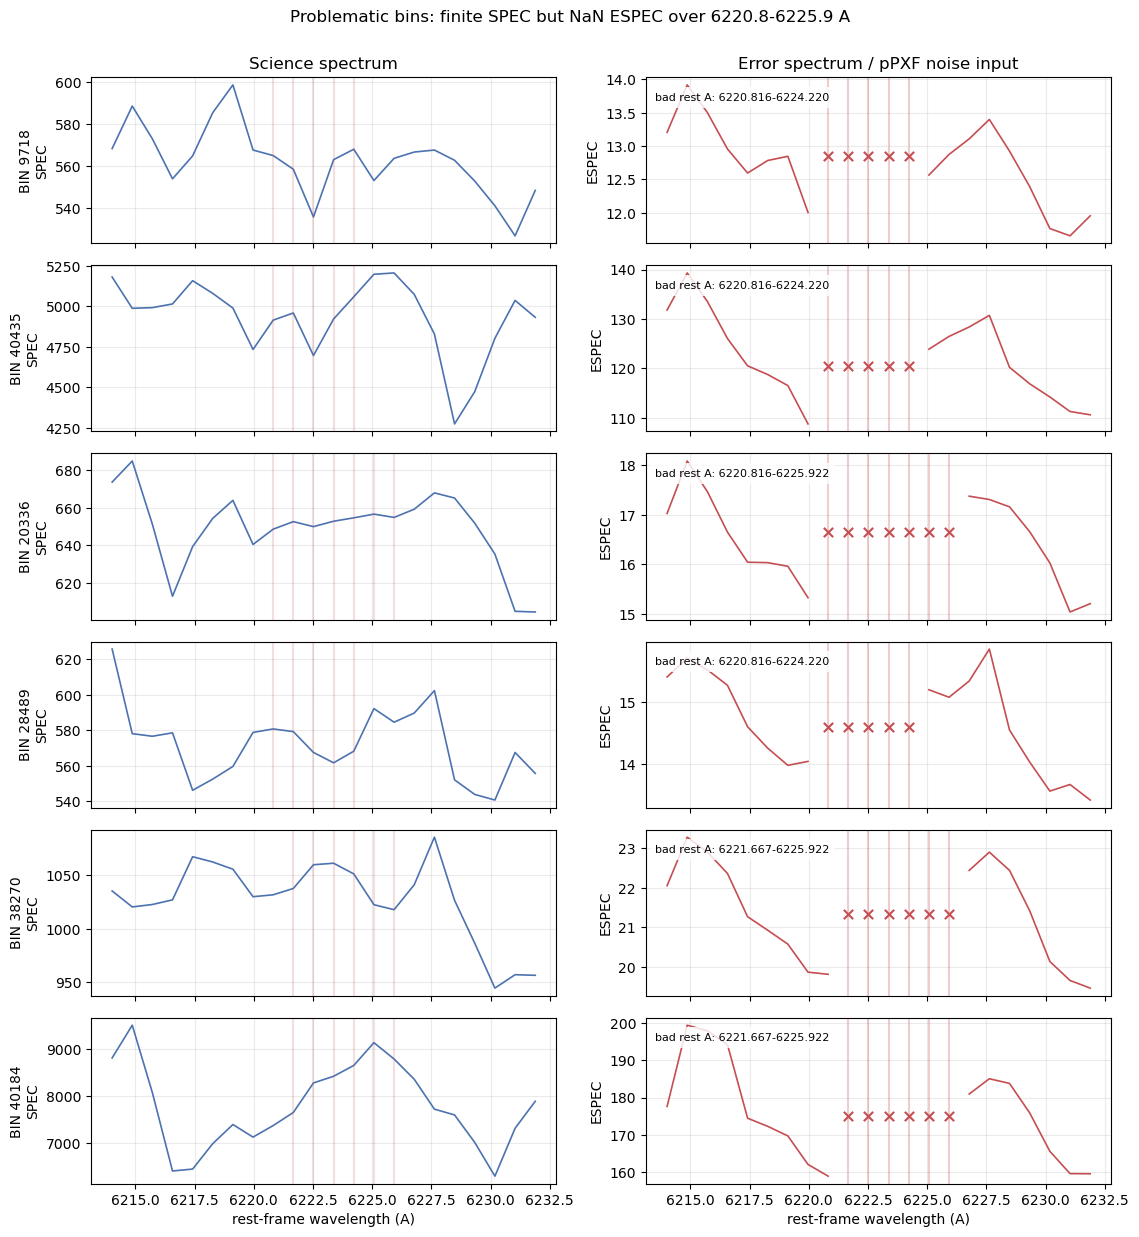

Sample problematic BINIDs plotted: [9718, 40435, 20336, 28489, 38270, 40184]
BINID 9718: rest 6220.816-6224.220 A, observed 6270.744-6274.175 A, map center x=422.8, y=302.0, npix=10
BINID 40435: rest 6220.816-6224.220 A, observed 6270.744-6274.175 A, map center x=707.6, y=13.4, npix=526
BINID 20336: rest 6220.816-6225.922 A, observed 6270.744-6275.892 A, map center x=355.5, y=593.6, npix=18
BINID 28489: rest 6220.816-6224.220 A, observed 6270.744-6274.175 A, map center x=599.1, y=622.9, npix=8
BINID 38270: rest 6221.667-6225.922 A, observed 6271.602-6275.892 A, map center x=644.2, y=884.6, npix=40
BINID 40184: rest 6221.667-6225.922 A, observed 6271.602-6275.892 A, map center x=323.0, y=1161.6, npix=2411


In [12]:
# CODEx NGC4254 extra diagnostic cell: several bad-bin spectra and ESPEC vectors
# Use labelled bins plus the bins with largest affected area; keep the plot readable.
candidate_ids = []
for bid in label_ids:
    if bid not in candidate_ids:
        candidate_ids.append(bid)
for row in sorted(problem_bin_spatial, key=lambda r: r["npix"], reverse=True):
    if row["BINID"] not in candidate_ids:
        candidate_ids.append(row["BINID"])
    if len(candidate_ids) >= 6:
        break
sample_bad_ids = candidate_ids[:6]

with h5py.File(BINSPEC, "r") as f:
    spec_samples = {bid: f["SPEC"][:, bid] for bid in sample_bad_ids}
    err_samples = {bid: f["ESPEC"][:, bid] for bid in sample_bad_ids}

zoom = (wave > 6213.5) & (wave < 6232.5)
fig, axs = plt.subplots(len(sample_bad_ids), 2, figsize=(11.5, 2.05 * len(sample_bad_ids)), sharex=True)
if len(sample_bad_ids) == 1:
    axs = np.array([axs])

for row_idx, bid in enumerate(sample_bad_ids):
    spec_vec = spec_samples[bid]
    err_vec = err_samples[bid]
    bad = np.where(~np.isfinite(err_vec) | (err_vec <= 0))[0]
    detail = next(r for r in problem_bin_details if r["BINID"] == bid)

    ax_s, ax_e = axs[row_idx]
    ax_s.plot(wave[zoom], spec_vec[zoom], color="#4c72b0", lw=1.2)
    ax_s.set_ylabel(f"BIN {bid}\nSPEC")
    ax_s.grid(alpha=0.25)
    ax_s.set_title("Science spectrum" if row_idx == 0 else "")

    ax_e.plot(wave[zoom], err_vec[zoom], color="#c44e52", lw=1.2)
    for rr in bad:
        ax_s.axvline(wave[rr], color="#c44e52", alpha=0.18)
        ax_e.axvline(wave[rr], color="#c44e52", alpha=0.28)
    finite_zoom_err = err_vec[zoom][np.isfinite(err_vec[zoom])]
    y_marker = np.nanmedian(finite_zoom_err) if finite_zoom_err.size else 0
    ax_e.scatter(wave[bad], np.full_like(bad, y_marker, dtype=float), color="#c44e52", marker="x", s=45, zorder=5)
    ax_e.set_ylabel("ESPEC")
    ax_e.grid(alpha=0.25)
    ax_e.set_title("Error spectrum / pPXF noise input" if row_idx == 0 else "")
    ax_e.text(0.02, 0.86, f"bad rest A: {detail['rest_A']}", transform=ax_e.transAxes, fontsize=8,
              bbox=dict(facecolor="white", alpha=0.82, edgecolor="none"))

axs[-1, 0].set_xlabel("rest-frame wavelength (A)")
axs[-1, 1].set_xlabel("rest-frame wavelength (A)")
fig.suptitle("Problematic bins: finite SPEC but NaN ESPEC over 6220.8-6225.9 A", y=1.002)
fig.tight_layout()
plt.show()

print("Sample problematic BINIDs plotted:", sample_bad_ids)
for bid in sample_bad_ids:
    d = next(r for r in problem_bin_details if r["BINID"] == bid)
    print(f"BINID {bid}: rest {d['rest_A']} A, observed {d['obs_A']} A, map center x={d['x_mean']:.1f}, y={d['y_mean']:.1f}, npix={d['npix']}")

## 8e. Why 6220-6225 A?

The local evidence does **not** prove the physical origin yet, but it constrains the likely cause.

- The bad interval is `6220.8-6225.9 A` in the rest-frame grid, which is `6270.7-6275.9 A` observed for `z = 0.008026`.
- That is not the AO/LGS fill interval after the rest-frame correction (`5724.1-6001.8 A` rest), so this is probably a separate issue from the AO/LGS replacement block.
- It is just blueward of the current rest-frame mask for the observed `[O I] 6300` sky line. In this config the `sky` entry at observed `6300 A` maps to about `6250 A` rest and, with width `30 A`, covers about `6234.8-6264.8 A` rest. The bad rows at `6220.8-6225.9 A` sit outside that lower edge.
- In observed-frame wavelength, `6271-6276 A` is close to the atmospheric/telluric O2 gamma-band region rather than the Na laser region. A plausible guess is that the input cube variance/error extension has a sparse bad or masked wavelength slice there, and `prepareSpectra` propagates it into binned `ESPEC`.
- The strongest code-level reason it reaches KIN is that `prepareSpectra/default.py` uses `np.nansum` for binned `SPEC`, but uses plain `np.sum` before `sqrt` for binned error spectra. One NaN error value in a contributing spaxel therefore contaminates that binned error pixel.

Suggested confirmation test: on Setonix, inspect the original cube variance extension and/or `NGC4254_all_spectra.hdf5` at observed `6270.7-6275.9 A` for the spatial pixels belonging to `BINID=9718`. If the NaNs are already present before spatial binning, the origin is the input variance/error cube or the log-rebinning of that cube; if not, the origin is the spatial error-combination step.

## 9. Code-path evidence

The observed `IndexError` is a wrapper-side symptom. The real pPXF failure is swallowed by a bare `except`, then the caller tries to unpack an EBV value that the fallback tuple does not contain.

In [13]:
def excerpt(path, start, end):
    lines = path.read_text(errors="replace").splitlines()
    print(f"\n--- {path}:{start}-{end} ---")
    for lineno in range(start, end + 1):
        print(f"{lineno:5d}: {lines[lineno - 1]}")

excerpt(PPXF_WRAPPER, 483, 496)
excerpt(PPXF_WRAPPER, 980, 990)
excerpt(PREPARE_SPECTRA, 274, 285)
excerpt(MUSE_WFMAON, 134, 153)


--- /Users/Igniz/nGISTENV/ngist/ngistPipeline/stellarKinematics/ppxf_kin_wrapper.py:483-496 ---
  483:         return(
  484:             pp.sol[:],
  485:             pp.bestfit,
  486:             optimal_template,
  487:             mc_results,
  488:             formal_error,
  489:             spectral_mask,
  490:             snr_postfit,
  491:             pp.chi2,
  492:             EBV,
  493:         )
  494: 
  495:     except:
  496:         return (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)

--- /Users/Igniz/nGISTENV/ngist/ngistPipeline/stellarKinematics/ppxf_kin_wrapper.py:980-990 ---
  980:         # Unpack results
  981:         for i in range(0, nbins):
  982:             ppxf_result[i, : config["KIN"]["MOM"]] = ppxf_tmp[i][0]
  983:             ppxf_bestfit[i, :] = ppxf_tmp[i][1]
  984:             optimal_template[i, :] = ppxf_tmp[i][2]
  985:             mc_results[i, : config["KIN"]["MOM"]] = ppxf_tmp[i][3]
  986:             formal_error[i, :

## 10. Findings, root cause, and next actions

### Findings

- The AO/LGS rest-frame correction fixed the earlier catastrophic read/masking failure. The previous failed mask had `MASK_DEFUNCT=1` for all 1,204,280 spaxels; the current mask rejects 161,822 spaxels and leaves 1,042,458 unmasked.
- The long Voronoi stage is consistent with the current products. The run binned 1,042,458 unmasked spaxels into 40,563 Voronoi bins with `TARGET_SNR=40`. This is a very large active footprint for Voronoi, so the 7.5 hr runtime is plausible from the local artifacts.
- The KIN crash is not caused by missing Galactic EBV in `CONFIG`; `READ_DATA: EBmV` is present. The failing EBV line is a secondary symptom.
- The binned spectra file contains 185 bins with non-finite `ESPEC`, starting at `BINID=9718`. `SPEC` is finite in those bins.
- The bad `ESPEC` pixels are localized at rest-frame `6220.8-6225.9 A`, observed-frame `6270.7-6275.9 A` for `z=0.008026`.
- The current KIN mask does not cover this interval. More importantly, pPXF checks that the entire noise vector is positive and finite before applying the spectral mask, so masking alone does not prevent the assertion.

### Root Cause Chain

1. The local binned HDF5 input to KIN has NaNs in `ESPEC` for 185 binned spectra.
2. pPXF receives one of those vectors as `noise` and rejects it because `noise` must be positive and finite.
3. `run_ppxf()` catches the true pPXF exception with a bare `except` and returns an 8-element tuple of NaNs.
4. The parallel unpacking loop expects a 9-element successful result tuple including EBV.
5. The module therefore crashes at `EBV[i] = ppxf_tmp[i][8]`, hiding the original pPXF noise error.

### Next Suggested Tests On Setonix

- Add temporary exception logging inside `run_ppxf()` with the bin index `i` and full traceback, then run a serial or `DEBUG_BIN` KIN test on `BINID=9718`. Expected original error: pPXF should complain that `NOISE` is not a positive finite vector.
- Inspect `NGC4254_all_spectra.hdf5` and, if available, `NGC4254_bin_spectra_linear.hdf5` around rest `6220.8-6225.9 A`. This will show whether the NaNs enter before log rebinning, during log rebinning, or during spatial binning of log-rebinned error spectra.
- Inspect the original cube variance/error extension near observed `6270.7-6275.9 A` at the affected spatial locations. This tests whether the defect originates in the input variance plane.

### Patch Options

- First patch the wrapper diagnostics: catch `Exception as exc`, log `BINID`, traceback, and return a 9-element failure tuple including `EBV=np.nan`. This avoids the misleading tuple-index crash and lets nGIST report bad bins cleanly.
- Fix data handling before pPXF: replace non-finite `ESPEC` values with finite conservative noise values, preferably by local wavelength interpolation or a deliberately large finite error, and record the affected rows/bins in QC output.
- Consider changing `prepareSpectra/default.py` so binned errors are robust to sparse NaNs. The current code uses `np.nansum` for `SPEC` but plain `np.sum` for errors, so one NaN input error can contaminate a binned error pixel.
- Add a KIN spectral mask around rest `6220.5-6226.5 A` only after the noise vector is made finite. It is useful scientifically, but not sufficient by itself because pPXF validates `noise` before masking.

## 11. Test with original `NGC4254_all_spectra.hdf5`

As suggested, we check the unbinned `ESPEC` values for the spaxels belonging to the first problematic bin (`BINID=9718`). By not loading the entire dataset into memory, we avoid memory issues.

In [14]:
ALL_SPECTRA = "/Volumes/Untitled/v3tk_v7.6.8/NGC4254/NGC4254_all_spectra.hdf5"

with fits.open(BINMAP, memmap=True) as hdul:
    binid_2d = np.asarray(hdul["BINID"].data, dtype=float)

# nGIST flattens the spatial dimensions (y, x) into a 1D array of spectra.
binid_1d = binid_2d.ravel()
spaxel_indices = np.where(binid_1d == first_bad)[0]
print(f"Spaxel indices for BINID {first_bad}: {spaxel_indices.tolist()}")

with h5py.File(ALL_SPECTRA, "r") as f:
    spaxel_indices_sorted = np.sort(spaxel_indices)
    
    # ESPEC shape is (nlam, nspaxels). We load only the required spaxels.
    espec_unbinned = f["ESPEC"][:, spaxel_indices_sorted]
    spec_unbinned = f["SPEC"][:, spaxel_indices_sorted]
    
    # Check for NaNs or non-positive values
    bad_unbinned = ~np.isfinite(espec_unbinned) | (espec_unbinned <= 0)
    
    if bad_unbinned.any():
        bad_rows = np.where(bad_unbinned.any(axis=1))[0]
        print(f"NaNs/non-positive ESPEC found in unbinned data at rows: {bad_rows.tolist()}")
        print(f"Corresponding observed wavelengths: {(wave[bad_rows] * (1+z)).tolist()}")
    else:
        print("No NaNs/non-positive ESPEC found in the unbinned spectra for this bin.")


Spaxel indices for BINID 9718: [305034, 305035, 305036, 306045, 306046, 306047, 306048, 307058, 307059, 307060]
NaNs/non-positive ESPEC found in unbinned data at rows: [1896, 1897, 1898, 1899, 1900]
Corresponding observed wavelengths: [6270.744042435723, 6271.601696057016, 6272.459466980137, 6273.317355221117, 6274.175360796014]


### Conclusion on the origin of NaNs

The test confirms that the NaNs are already present in the unbinned error spectra (`NGC4254_all_spectra.hdf5`) for the exact spaxels belonging to `BINID 9718`. The affected rows match exactly the wavelength range where the binned error spectrum is bad.

**This means the origin of the NaNs is *before* the spatial error-combination step.** The defect must originate from the input cube's variance extension itself, or during the initial log-rebinning of that cube in `readData`.